In [28]:
import pandas as pd
import warnings

from dmm.config_options import Conf
from sensitivity import *
from training_configuration import (
    LATENT_DIMS,
    NETWORK_DEPTH,
    DROPOUT_RATES,
    L1_INFLATE_OUTPUT_REGS,
    INFLATER_OUTPUT_REG_EPOCHS,
    INFLATER_BOUND,
    RECON_REGS,
    NEPOCH,
    SPLITS,
)
from common import TRAINED_MODEL
warnings.filterwarnings("ignore")

ERROR! Session/line number was not unique in database. History logging moved to new session 1050


In [29]:
conf = Conf(
    model = "EGFR_MAPK__logobs_tegfr_aggavg",  # base model
    data = "dream_cytof",
    n_hidden = LATENT_DIMS["central_value"],
    depth = NETWORK_DEPTH["central_value"],
    dropout_rate = DROPOUT_RATES["central_value"],
    l1reg_inflater_output = L1_INFLATE_OUTPUT_REGS["central_value"],
    inflater_output_reg_epoch = INFLATER_OUTPUT_REG_EPOCHS["central_value"],
    inflater_bound = INFLATER_BOUND["central_value"],
    oreg_inflate=0,
    oreg_encode=0,
    l1reg_encode=0,
    l1reg_inflate=0,
    l2reg_inflater_output = 0,
    recon_loss = RECON_REGS["central_value"],
    symm_reg= 0,
    n_epoch = NEPOCH["central_value"],
    multiheaded=False,
)

In [ ]:
results_params_df, results_latent_df = compute_sensitivities(
    conf=conf,
    context_features=[("cytof_init", "RFE_8_permute"),],
    splits=["all",],
    latent_sensitivities={"cytof_init": True},
    n_jobs=10,
    multiheaded_multimodal=True,
)

results_params_df.to_csv(
    "sensitivity_analysis_params.csv",
    index=False
)
results_latent_df.to_csv(
    "sensitivity_analysis_latent.csv",
    index=False
)

context=cytof_init, split=all_plus_missingtx, job=0, params: 100%|██████████| 44/44 [01:54<00:00,  2.61s/it]
context=cytof_init, split=all_plus_missingtx, job=0, latents: 100%|██████████| 4/4 [00:06<00:00,  1.57s/it]
context=cytof_init, split=all_plus_missingtx, job=1, params: 100%|██████████| 44/44 [02:36<00:00,  3.55s/it]
context=cytof_init, split=all_plus_missingtx, job=1, latents: 100%|██████████| 4/4 [00:08<00:00,  2.03s/it]
context=cytof_init, split=all_plus_missingtx, job=2, params: 100%|██████████| 44/44 [01:51<00:00,  2.54s/it]
context=cytof_init, split=all_plus_missingtx, job=2, latents: 100%|██████████| 4/4 [00:08<00:00,  2.13s/it]
context=cytof_init, split=all_plus_missingtx, job=3, params: 100%|██████████| 44/44 [01:54<00:00,  2.61s/it]
context=cytof_init, split=all_plus_missingtx, job=3, latents: 100%|██████████| 4/4 [00:07<00:00,  1.95s/it]
context=cytof_init, split=all_plus_missingtx, job=4, params: 100%|██████████| 44/44 [16:54<00:00, 23.07s/it]   
context=cytof_init, 

## Reload from here directly

In [34]:
results_params_df = pd.read_csv("sensitivity_analysis_params.csv")
results_latent_df = pd.read_csv("sensitivity_analysis_latent.csv")

Index(['RPS6KA1_p_S380_ERK__Y204_p_kw', 'ERK_p_Y204_MEK__S222_p_kw',
       'ERBB2_p_Y1248_ERBB2_kw', 'ERK_p_Y204_TOPK__Y74_p_kw',
       'ERBB2_p_Y1248_EGFR__Y1173_p_kw', 'MEK_p_S222_ERK__Y204_p_kw',
       'ERBB2_p_Y1248_ERBB3__Y1289_p_kw', 'MEK_p_S222_EGFR__Y1173_p_kw',
       'EGFR_deg_kdeg', 'RPS6KA1_p_S380_bact'],
      dtype='object', name='param')


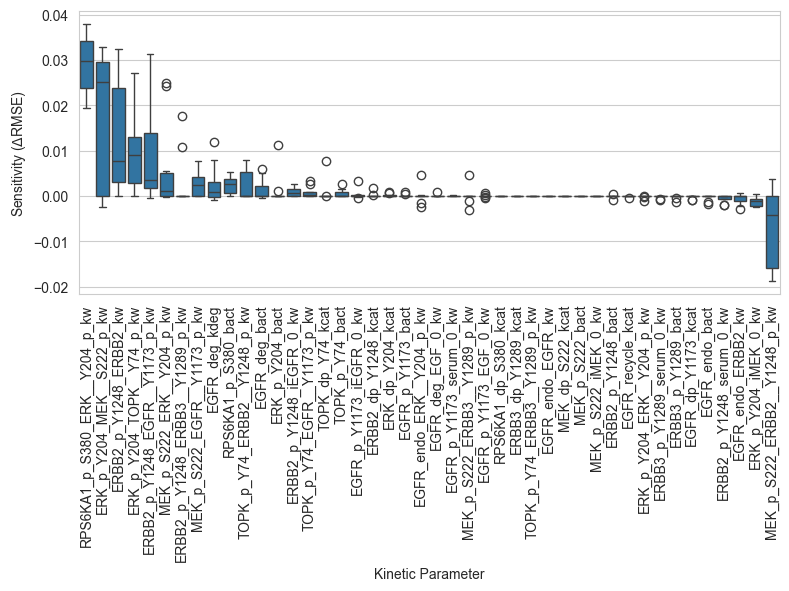

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns


df = results_params_df[
    (results_params_df.context == "cytof_init") &
    (results_params_df.dataset == "train")
]

# compute mean rmse_diff per param
order = (
    df.groupby("param")["rmse_diff_zeroed"]
      .mean()
      .sort_values(ascending=False)
      .index
)

print(order[:10])

plt.figure(figsize=(8, 6))
# plot with that order
sns.boxplot(
    data=df,
    x="param",
    y="rmse_diff_zeroed",
    order=order,
)

plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
plt.xlabel("Kinetic Parameter")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show();

In [39]:
df

,context,samples,job,param,dataset,rmse_pristine,rmse_zeroed,rmse_activated,rmse_diff_zeroed,rmse_diff_activated,receptor_group
0,cytof_init,all_plus_missingtx,0,ERBB3_dp_Y1289_kcat,train,0.482771,0.482771,0.482771,0.000000,0.000000,Other
2,cytof_init,all_plus_missingtx,0,ERBB2_dp_Y1248_kcat,train,0.482771,0.482771,0.482771,0.000000,0.000000,ERBB2
4,cytof_init,all_plus_missingtx,0,EGFR_deg_kdeg,train,0.482771,0.482771,0.482771,0.000000,0.000000,EGFR
6,cytof_init,all_plus_missingtx,0,EGFR_dp_Y1173_kcat,train,0.482771,0.482771,0.482771,0.000000,0.000000,EGFR
8,cytof_init,all_plus_missingtx,0,EGFR_recycle_kcat,train,0.482771,0.482771,0.482771,0.000000,0.000000,EGFR
...,...,...,...,...,...,...,...,...,...,...,...
870,cytof_init,all_plus_missingtx,9,ERK_p_Y204_TOPK__Y74_p_kw,train,0.473474,0.478481,0.572379,0.005007,0.098905,Other
872,cytof_init,all_plus_missingtx,9,ERK_p_Y204_iMEK_0_kw,train,0.473474,0.471245,0.595014,-0.002229,0.121540,Other
874,cytof_init,all_plus_missingtx,9,ERK_p_Y204_ERK__Y204_p_kw,train,0.473474,0.473474,0.473474,0.000000,0.000000,Other
876,cytof_init,all_plus_missingtx,9,RPS6KA1_p_S380_bact,train,0.473474,0.476269,0.571562,0.002796,0.098088,Other


Index(['ERK_p_Y204_iMEK_0_kw', 'EGFR_deg_kdeg',
       'ERBB2_p_Y1248_EGFR__Y1173_p_kw', 'ERK_p_Y204_MEK__S222_p_kw',
       'ERK_p_Y204_TOPK__Y74_p_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw',
       'ERBB2_p_Y1248_iEGFR_0_kw', 'MEK_p_S222_EGFR__Y1173_p_kw',
       'RPS6KA1_p_S380_bact', 'TOPK_p_Y74_EGFR__Y1173_p_kw'],
      dtype='object', name='param')


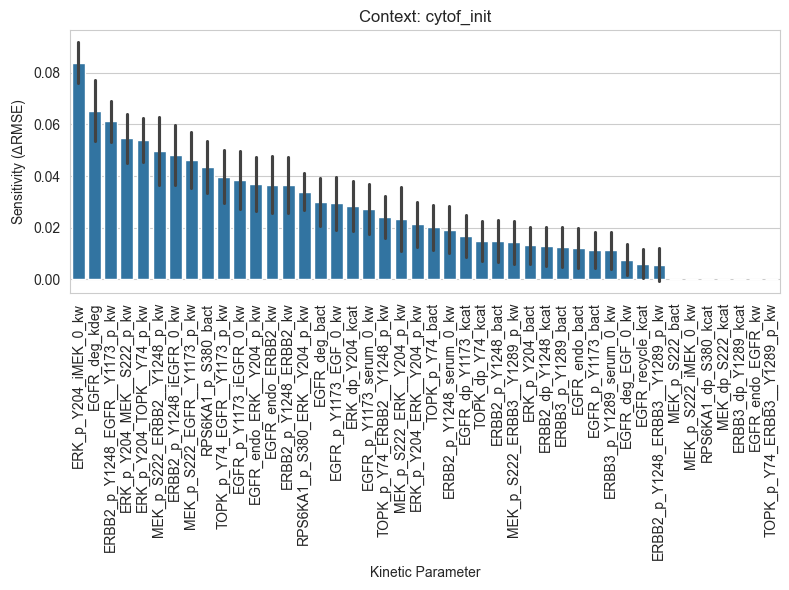

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns


for context, _ in [("cytof_init", "RFE_8_permute")]:
    df = results_params_df[(results_params_df.context == context)]

    # compute mean rmse_diff per param
    order = (
        df.groupby("param")["rmse_diff_activated"]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    print(order[:10])

    plt.figure(figsize=(8, 6))
    # plot with that order
    sns.barplot(
        data=df,
        x="param",
        y="rmse_diff_activated",
        order=order,
        errorbar='se'
    )

    plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
    plt.xlabel("Kinetic Parameter")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()